In [155]:
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pywt
from scipy import signal
from scipy.signal import resample_poly
from scipy.stats import skew, kurtosis # Importamos las funciones para skewness y kurtosis
import pandas as pd # Usaremos Pandas para mostrar los resultados de forma ordenada

In [156]:
# 1) archivos

npz_path = Path("../data/processed/S01_EEG.npz")
meta_path = npz_path.with_suffix(".meta.json")

# 2) Cargar datos y labels
npz = np.load(npz_path)
datos = npz["data"]         # shape (n_trials, total_samples)
x = datos[:, :-3]           # señales
y = datos[:, -3:]           # etiquetas
n_trials, total_samples = x.shape
print("n_trials, total_samples:", n_trials, total_samples)
print("y shape:", y.shape)

n_trials, total_samples: 688 24576
y shape: (688, 3)


In [157]:
# 3) Extraer fs desde metadata (si existe), sino usar default 1024
if meta_path.exists():
    meta = json.load(open(meta_path, "r", encoding="utf8"))
    fs = meta.get("fs", None)
    print("fs desde meta:", fs)
else:
    meta = {}
    fs = None
    print("No existe meta. Usarás fs por defecto o lo definirás manualmente.")

if fs is None:
    fs = 1024   # tu valor conocido; o setear otro si corresponde
    print("Usando fs por defecto:", fs)

# 4) Número de canales y samples por canal
n_channels = 6
if total_samples % n_channels != 0:
    raise ValueError(f"Total samples ({total_samples}) no divisible por {n_channels}. Revisá datos.")
samples_per_channel = total_samples // n_channels
duration_sec = samples_per_channel / fs
print("samples_per_channel:", samples_per_channel, "→ duración (s):", duration_sec)
# esperamos 4096 y 4.0 s

fs desde meta: 1024
samples_per_channel: 4096 → duración (s): 4.0


In [163]:
# 5) Remoldear a (n_trials, n_channels, samples_per_channel)
x_channels = x.reshape(n_trials, n_channels, samples_per_channel)
print("x_channels shape:", x_channels.shape)  # (688, 6, 4096) esperado

# 6) Mapear nombres de canales (según tu contexto)
channel_names = ["F3", "F4", "C3", "C4", "P3", "P4"]
print("Canales:", channel_names)

x_channels shape: (688, 6, 4096)
Canales: ['F3', 'F4', 'C3', 'C4', 'P3', 'P4']


In [178]:
# tomo un trial al azar
trial = np.random.randint(0, len(x_channels))

ejemplo = x_channels[trial]
etiqueta = y[trial]

print(ejemplo.shape, etiqueta)

(6, 4096) [1. 9. 2.]


In [179]:
# decodificar etiqueta
posible_modalidad = ['Imaginada', 'Pronunciada']
posible_estimulo = ['A', 'E', 'I', 'O', 'U', 'Arriba', 'Abajo', 'Adelante', 'Atras', 'Derecha', 'Izquierda']
posible_artefacto = ['Limpio', 'Parpadeo']

etiqueta_texto = [posible_modalidad[int(etiqueta[0]-1)], posible_estimulo[int(etiqueta[1]-1)], posible_artefacto[int(etiqueta[2]-1)]]
print(etiqueta)
print(etiqueta_texto)

[1. 9. 2.]
['Imaginada', 'Atras', 'Parpadeo']


In [180]:
# submuestrear ejemplo
fs_nueva = 128
tiempo_submuestreado = np.linspace(0, duration_sec, int(duration_sec*fs_nueva))

ejemplo_submuestreado = []
for i in ejemplo:
    aux = resample_poly(i, fs_nueva, fs)
    ejemplo_submuestreado.append(aux)
ejemplo_submuestreado = np.array(ejemplo_submuestreado)
print(ejemplo_submuestreado.shape)

(6, 512)


In [181]:
# DWT descomposition
wavelet = 'db4'
level = 5

all_coeffs = []
for canal_signal in ejemplo_submuestreado:
    # pywt.wavedec devuelve una lista de arrays: [cAn, cDn, cDn-1, ..., cD1]
    # donde 'n' es el nivel de descomposición.
    coeffs = pywt.wavedec(canal_signal, wavelet, level=level)
    all_coeffs.append(coeffs)

def generate_coeff_names(level: int) -> list[str]:
    if level < 1:
        return []
    names = [f'cA{level}']
    names.extend([f'cD{i}' for i in range(level, 0, -1)])
    return names

def generate_time_vectors(signal_duration: float, vec_coeff):
    """
    Genera vectores de tiempo para cada conjunto de coeficientes wavelet para su ploteo.
    """
    tiempos = []
    for i in vec_coeff:
        longitud = len(i)
        tiempos.append(np.linspace(0, duration_sec, longitud))
    return tiempos

coeff_names = generate_coeff_names(level)
print(f"Nombres para nivel {level}: {coeff_names}\n")

time_vectors = generate_time_vectors(duration_sec, all_coeffs[0])

print(len(time_vectors))
for i in time_vectors:
    print(len(i))

Nombres para nivel 5: ['cA5', 'cD5', 'cD4', 'cD3', 'cD2', 'cD1']

6
22
22
38
70
133
259


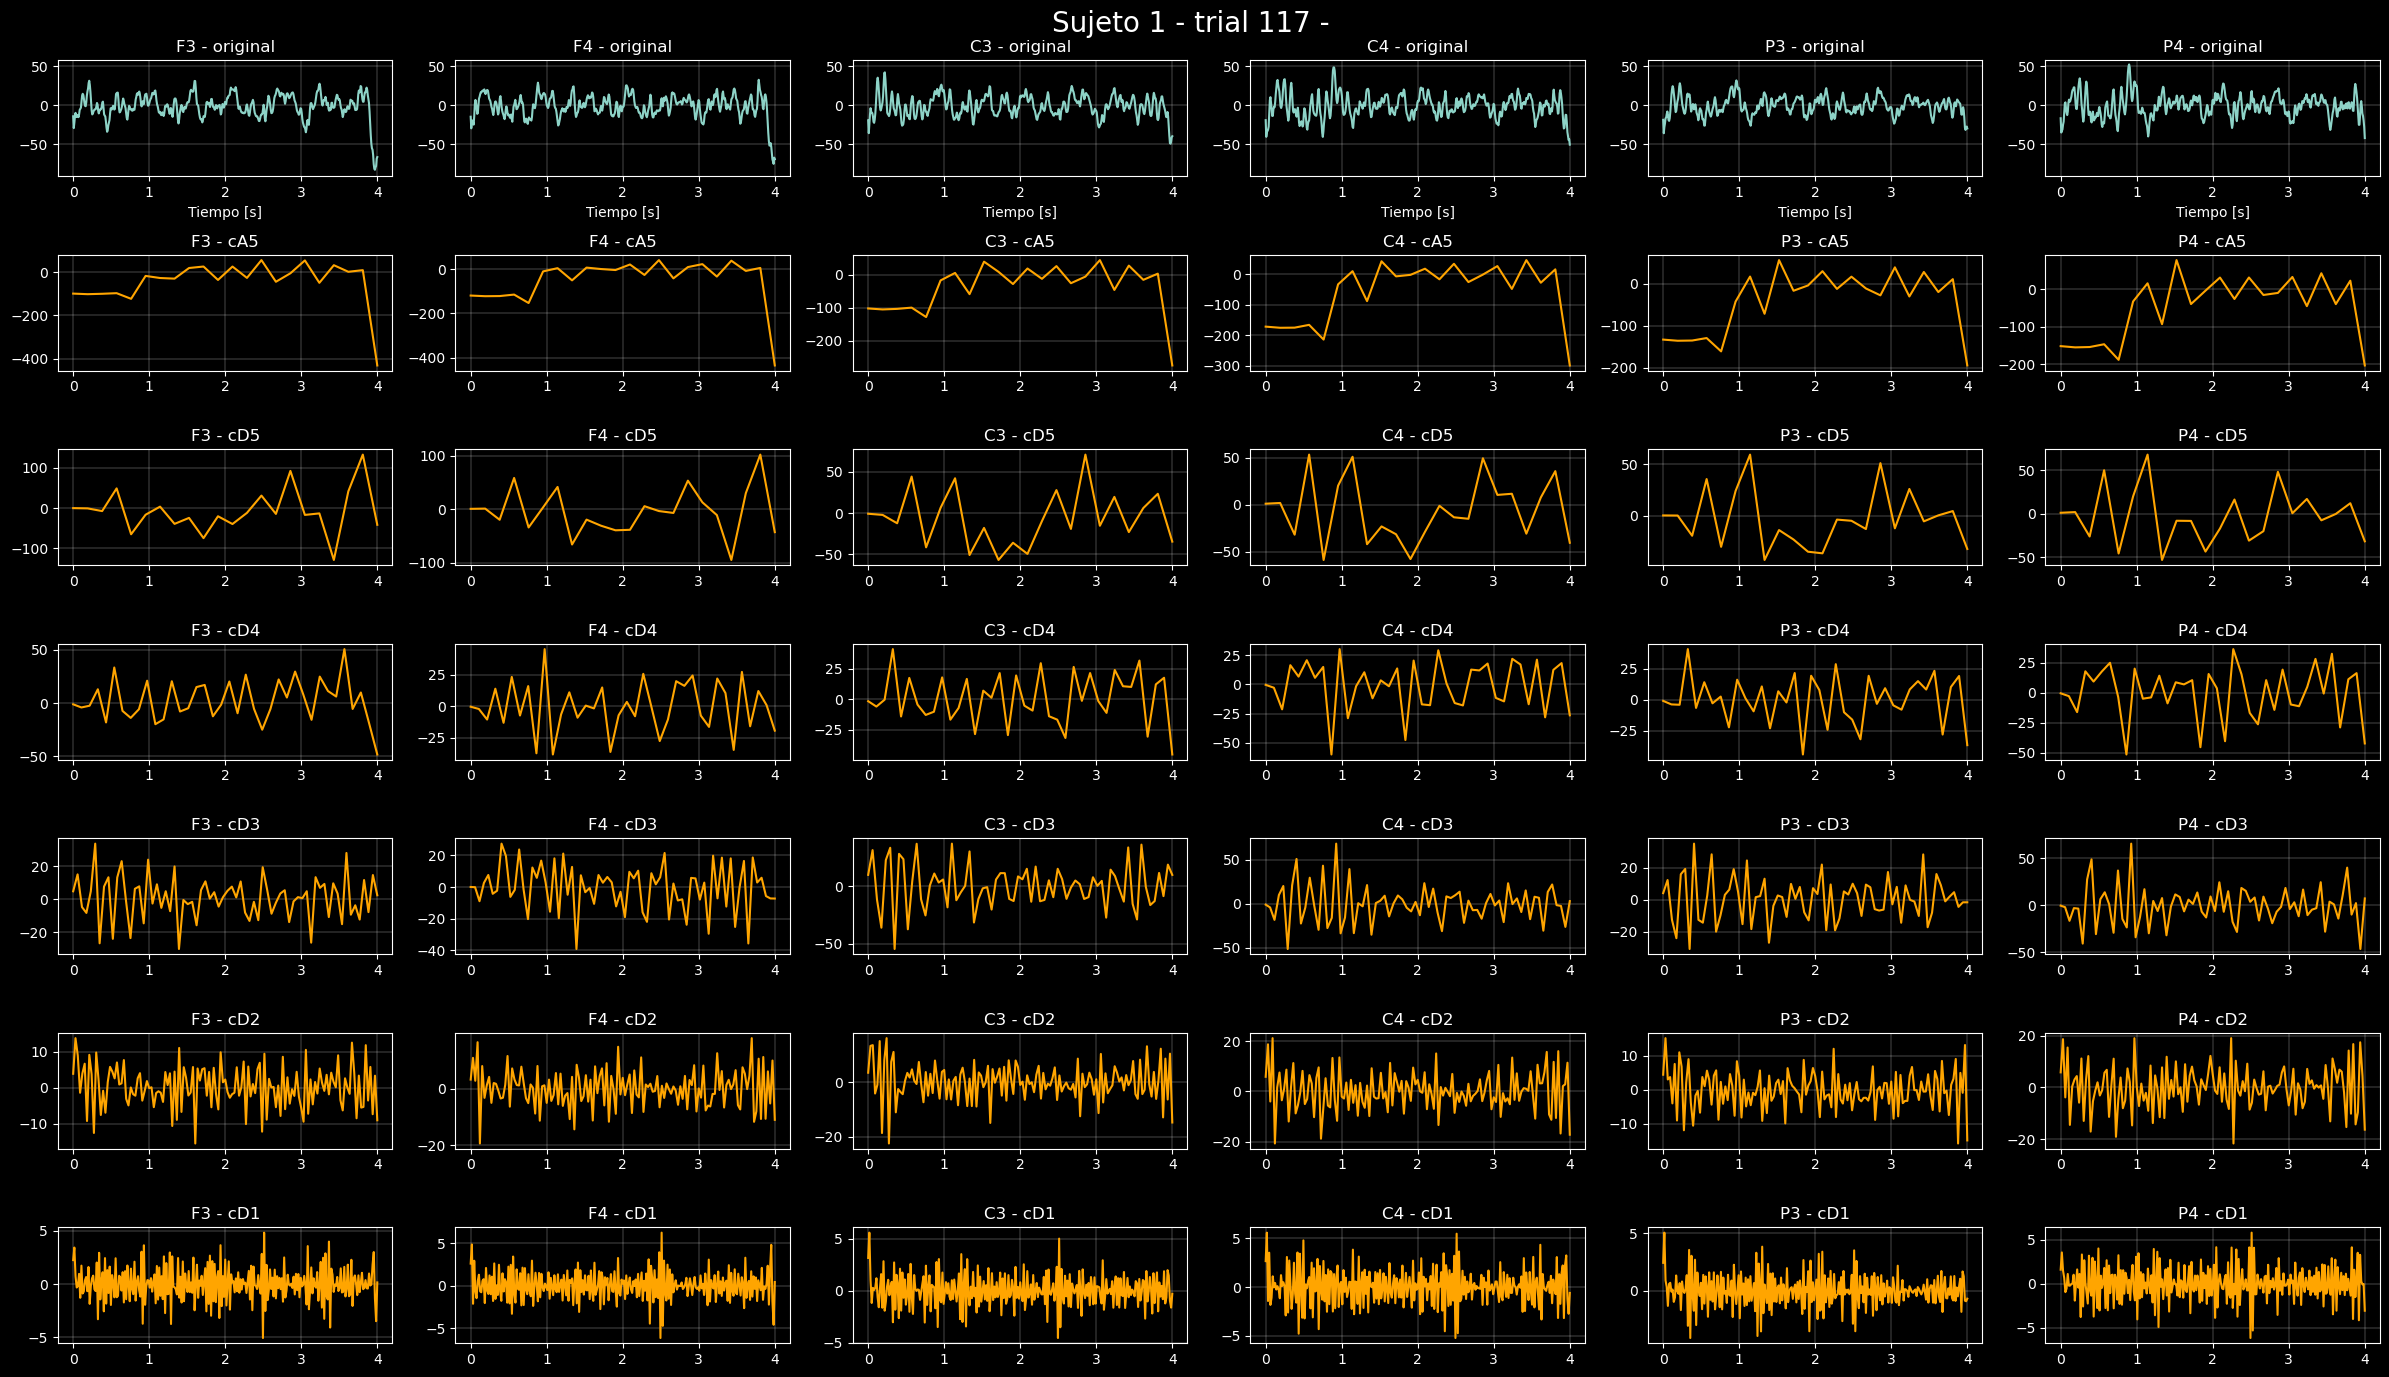

In [182]:
# graficamos matriz de coeficientes y señal original
maximo = np.max(ejemplo_submuestreado) * 1.1
minimo = np.min(ejemplo_submuestreado) * 1.1

plt.style.use('dark_background')
plt.figure(figsize = (24, 14))
plt.suptitle(f'Sujeto 1 - trial {trial} - ', fontsize = 20)
for i in range(len(all_coeffs)):    # en los canales
    plt.subplot(len(all_coeffs) + 1, level + 1, i+1)
    plt.plot(tiempo_submuestreado, ejemplo_submuestreado[i])
    plt.title(f'{channel_names[i]} - original')
    plt.xlabel('Tiempo [s]')
    plt.grid(lw = 0.2)
    plt.ylim((minimo, maximo))
    for j in range(level + 1):
        plt.subplot(len(all_coeffs) + 1, level + 1, i+1 + len(all_coeffs)*(j+1))
        plt.plot(time_vectors[j], all_coeffs[i][j], color = 'orange')
        plt.title(f'{channel_names[i]} - {coeff_names[j]}')
        plt.grid(lw = 0.2)
        #plt.ylim((maximo, minimo))
plt.tight_layout()
plt.show()

In [183]:
# estatistics features
def calculate_statistics(data: np.ndarray):
    """Calcula un conjunto de estadísticos para un array de datos."""
    stats = np.array([np.mean(data),
             np.mean(np.abs(data)),
             np.var(data),
             np.std(data),
             skew(data),
             kurtosis(data)])
    return stats

all_features = []
# Iteramos sobre cada canal en `all_coeffs`
for i in range(len(all_coeffs)):
    channel_features = []
    for j in range(level + 1):
        channel_features.append(calculate_statistics(all_coeffs[i][j]))
    all_features.append(channel_features)

all_features = np.array(all_features)
print(all_features.shape)

statistics_names = ['Media', 'Media absoluta', 'Varianza', 'Desviacion estandar', 'Skewness', 'Kurtosis']
for i in range(6):
    print(f'{statistics_names[i]} : {all_features[0][0][i]}')

(6, 6, 6)
Media : -43.781525125607416
Media absoluta : 64.24916356553965
Varianza : 9828.521463923591
Desviacion estandar : 99.13889985229608
Skewness : -2.6076157895067005
Kurtosis : 7.8276540771974545


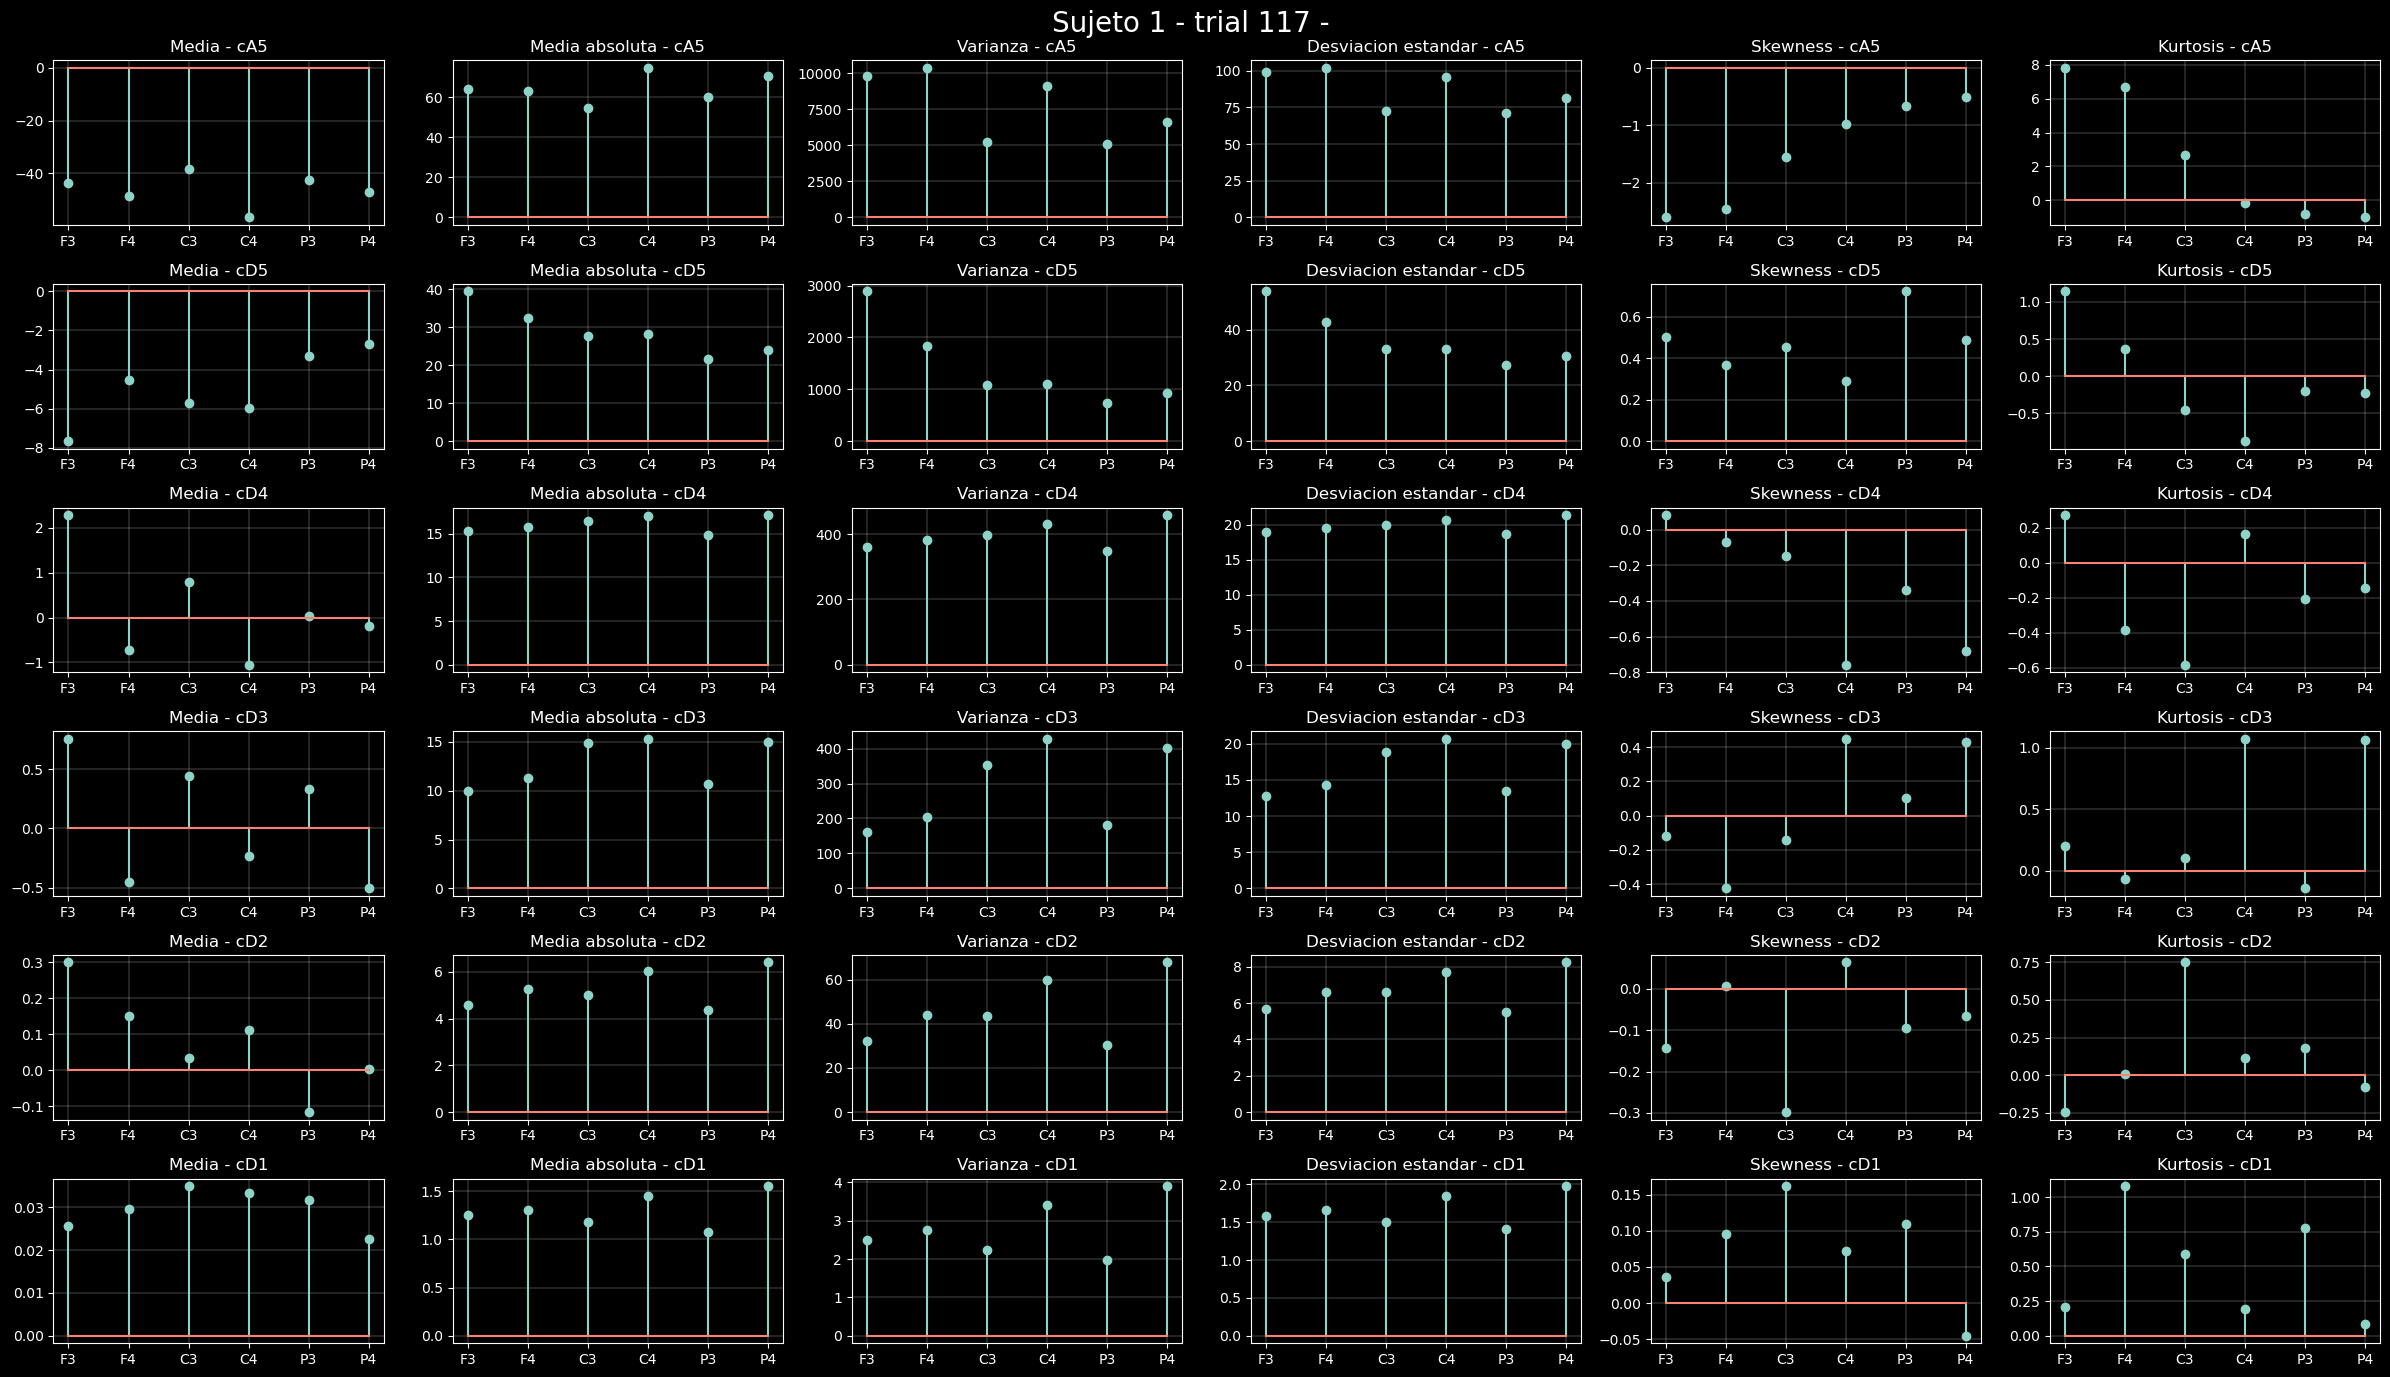

In [184]:
# grafico matriz estadisticos x nivel

plt.style.use('dark_background')
plt.figure(figsize = (24, 14))
plt.suptitle(f'Sujeto 1 - trial {trial} - ', fontsize = 20)
for i in range(all_features.shape[2]):
    for j in range(level + 1):
        plt.subplot(level + 1, all_features.shape[2], i+1 + j*all_features.shape[2])
        plt.stem(channel_names, all_features[:, j, i])
        plt.title(f'{statistics_names[i]} - {coeff_names[j]}')
        plt.grid(lw = 0.2)
plt.tight_layout()
plt.show()

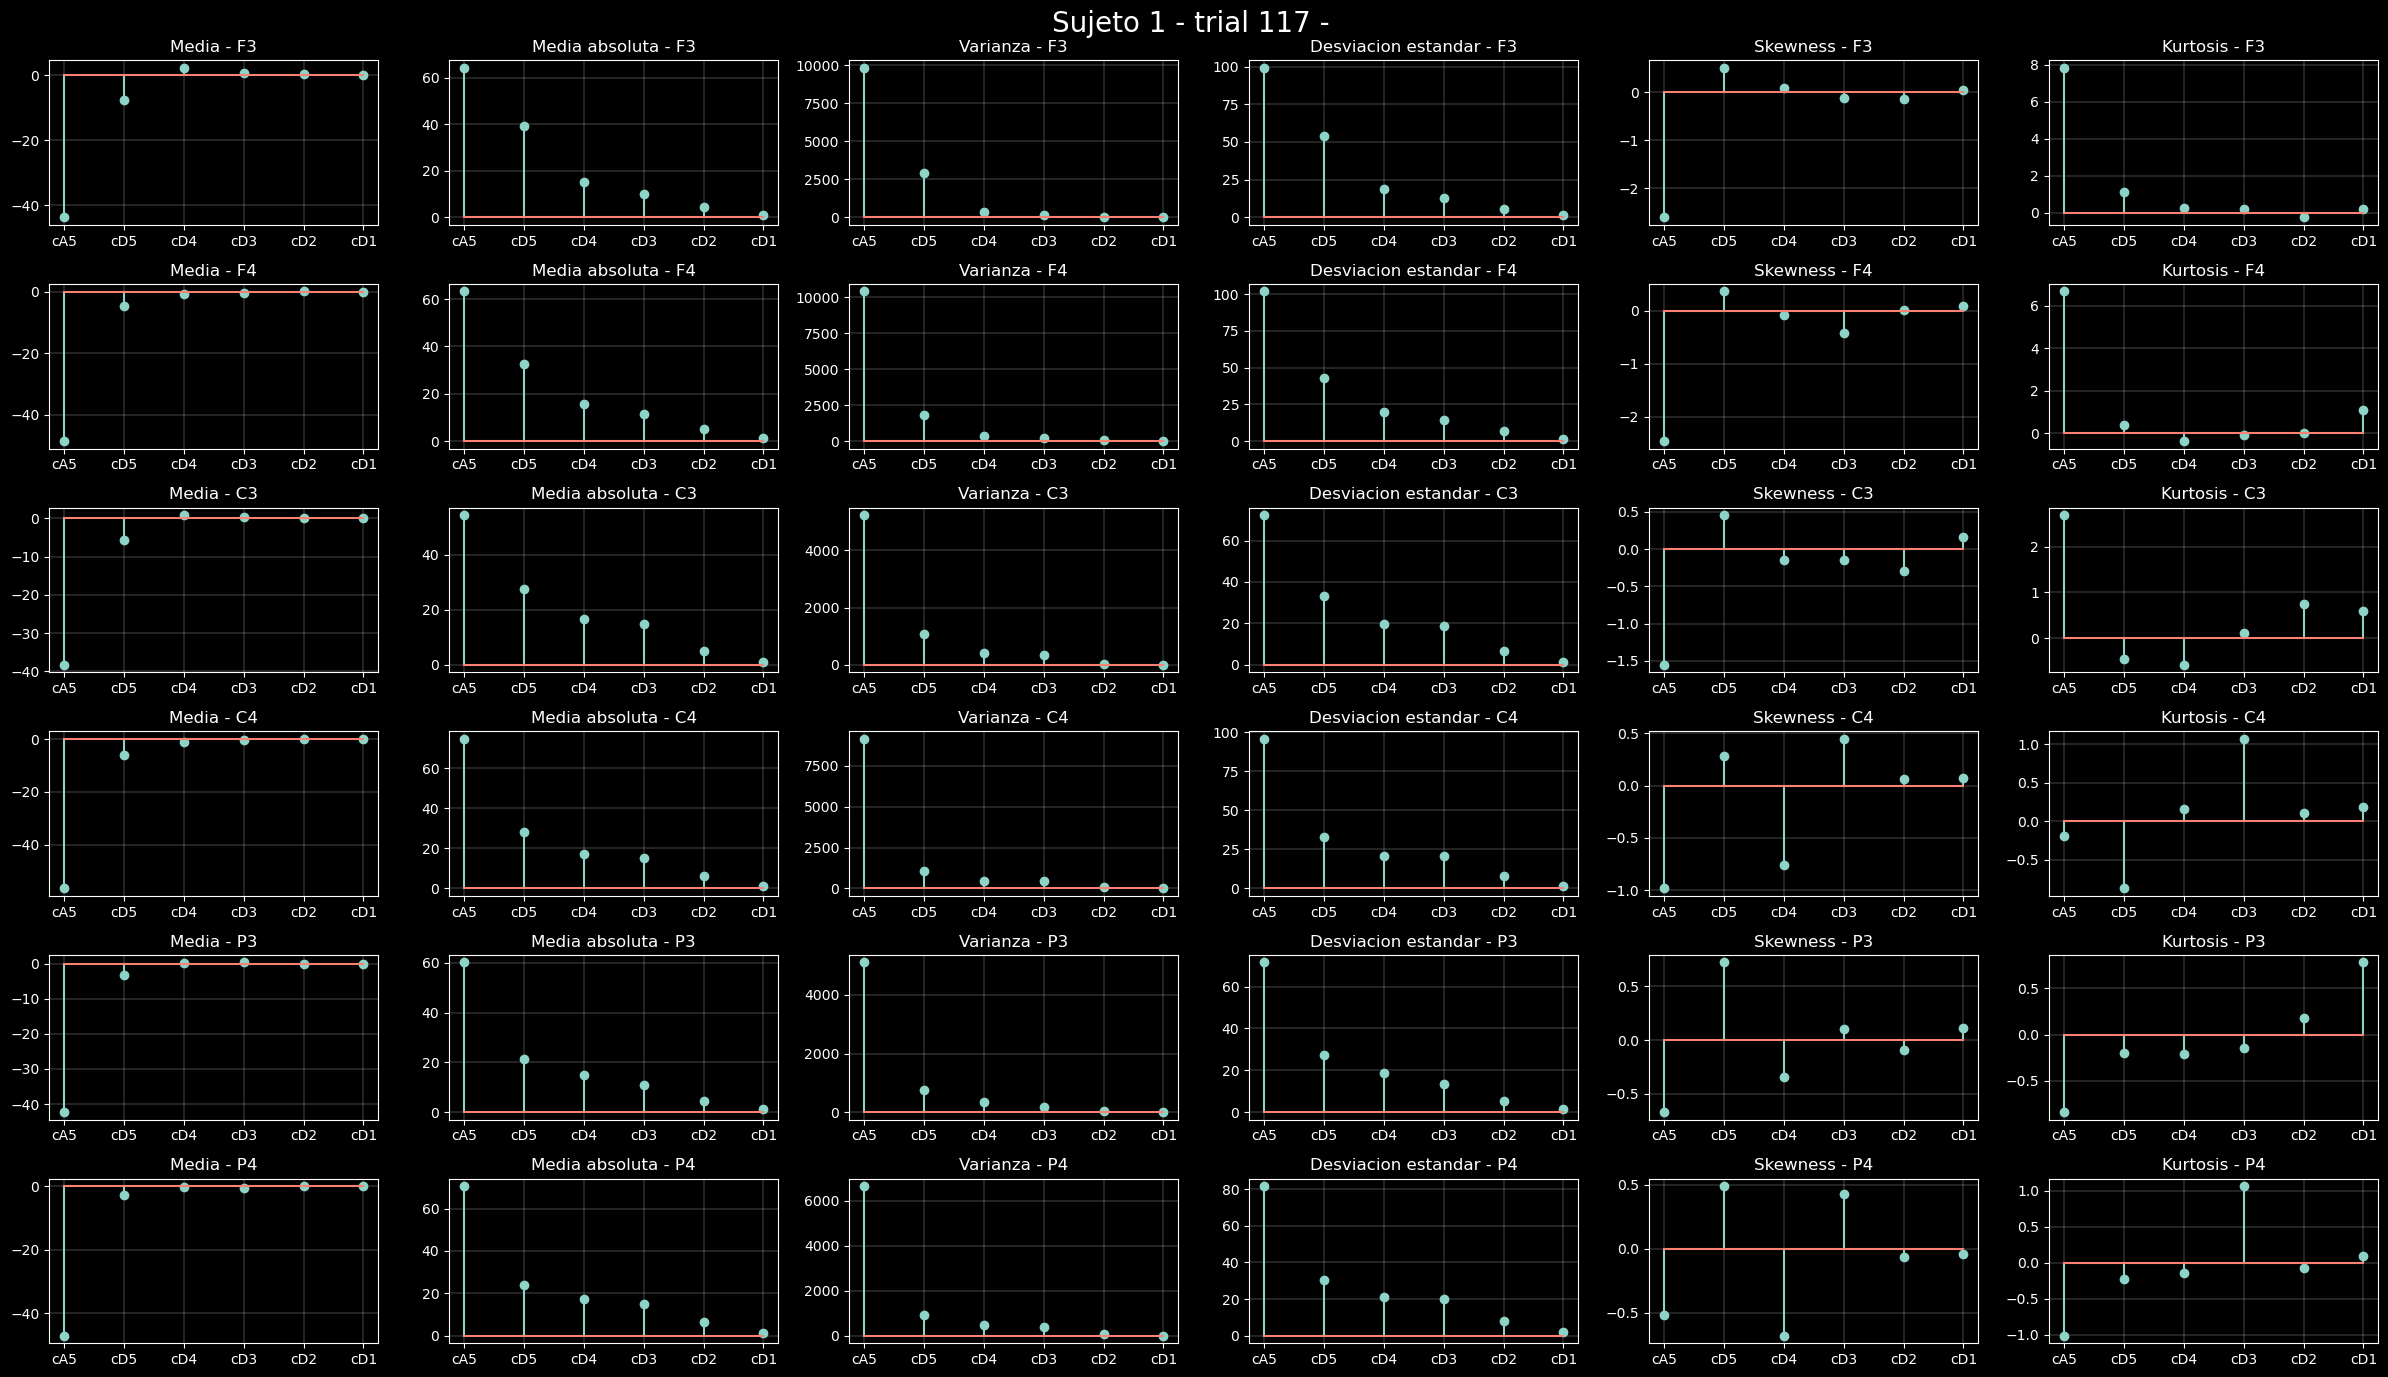

In [185]:
# grafico matriz estadisticos x canal

plt.style.use('dark_background')
plt.figure(figsize = (24, 14))
plt.suptitle(f'Sujeto 1 - trial {trial} - ', fontsize = 20)
for i in range(all_features.shape[2]):
    for j in range(n_channels):
        plt.subplot(level + 1, all_features.shape[2], i+1 + j*all_features.shape[2])
        plt.stem(coeff_names, all_features[j, :, i])
        plt.title(f'{statistics_names[i]} - {channel_names[j]}')
        plt.grid(lw = 0.2)
plt.tight_layout()
plt.show()

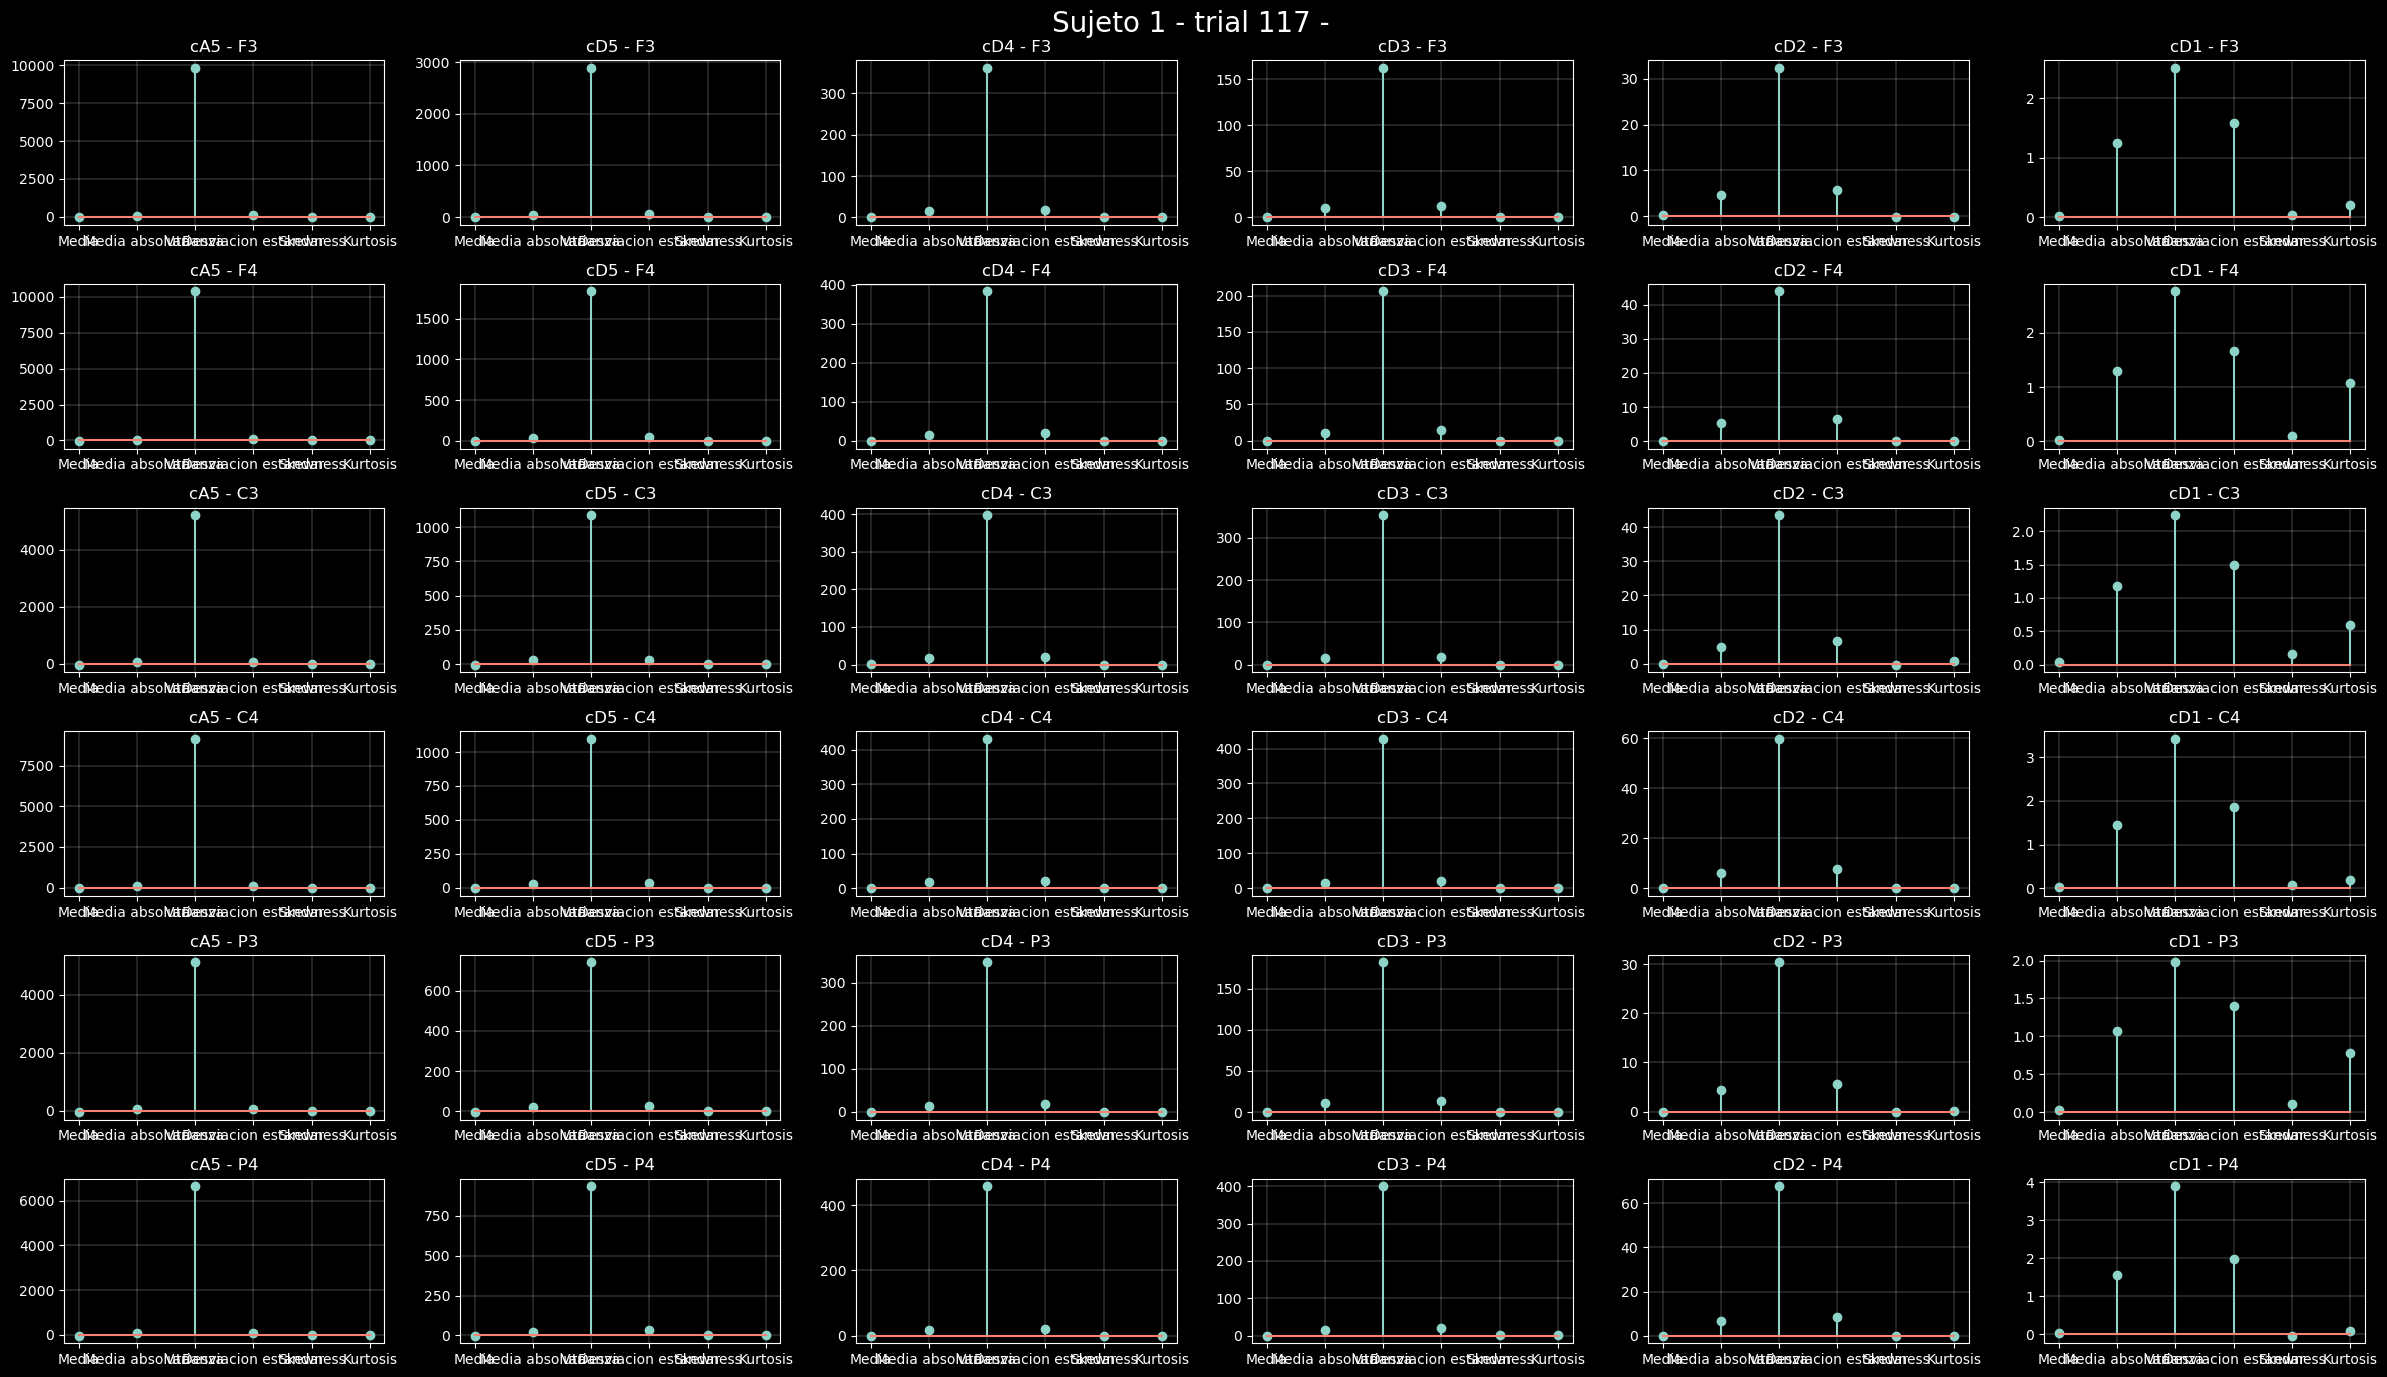

In [186]:
# grafico matriz canales x niveles

plt.style.use('dark_background')
plt.figure(figsize = (24, 14))
plt.suptitle(f'Sujeto 1 - trial {trial} - ', fontsize = 20)
for i in range(level + 1):
    for j in range(n_channels):
        plt.subplot(level + 1, n_channels, i+1 + j*n_channels)
        plt.stem(statistics_names, all_features[j, i, :])
        plt.title(f'{coeff_names[i]} - {channel_names[j]}')
        plt.grid(lw = 0.2)
plt.tight_layout()
plt.show()